In [ ]:
# Implementation of Granger Causality Test
# Author: Phoebe Kuang

import numpy as np
import lovelyplots # Credit: LovelyPlots (Package)
import matplotlib.pyplot as plt
plt.style.use(['ipynb', 'colors5-light'])

from scipy.stats import f
from statsmodels.tsa.stattools import adfuller, kpss

import warnings
warnings.filterwarnings("ignore")

In [2]:
# 1. DATA GENERATION & VALIDATION

# Helper fuctions

def validate_statistics(data, name):
    """
    Validates stationarity and prints summary statistics.
    """
    mean_val = np.mean(data)
    std_val = np.std(data, ddof=1)
    
    # ADF Test: p < 0.05 means stationary
    adf_p = adfuller(data)[1]
    # KPSS Test: p > 0.05 means stationary
    kpss_p = kpss(data)[1]

    # Referece: https://www.statsmodels.org/dev/examples/notebooks/generated/stationarity_detrending_adf_kpss.html
    
    print(f"Statistics for {name}:\n")
    print(f"-> Mean: {mean_val:.4f}, Std Dev: {std_val:.4f}")
    print(f"-> ADF p-value:  {adf_p:.4f} (Stationary if < 0.05)")
    print(f"-> KPSS p-value: {kpss_p:.4f} (Stationary if > 0.05)\n")
    
    return mean_val, std_val

def build_lag_matrix(series, p_lags):
    """
    Helper function to build feature matrices of shape (N-p, p)
     for p lags of the input series.
    """
    N = len(series)
    X = np.zeros((N - p_lags, p_lags))
    for i in range(p_lags):
        X[:, i] = series[p_lags - i - 1 : N - i - 1]
    return X

In [3]:
# 2. GRANGER CAUSALITY TEST (Post-Sample)

def granger_causality_test(driver, target, p_lags=2, test_ratio=0.2):
    """
    Tests if Driver => Target using out-of-sample standard deviations 
    of the forecast errors and an F-test.
    """
    N = len(target)
    
    # 1. Build the data matrices
    Y_target = target[p_lags:]
    Y_lags = build_lag_matrix(target, p_lags)
    X_lags = build_lag_matrix(driver, p_lags)
    
    # Add intercept column (ones)
    ones = np.ones((len(Y_target), 1))
    
    # Restricted Features: [Intercept, Past Y]
    Feature_Rest = np.column_stack([ones, Y_lags])
    
    # Unrestricted Features: [Intercept, Past Y, Past X]
    Feature_Unrest = np.column_stack([ones, Y_lags, X_lags])
    
    # 2. Train/Test Split
    split_idx = int(len(Y_target) * (1 - test_ratio))
    
    Y_train = Y_target[:split_idx]
    Y_test  = Y_target[split_idx:]
    
    # Train matrices
    FR_train, FR_test = Feature_Rest[:split_idx], Feature_Rest[split_idx:]
    FU_train, FU_test = Feature_Unrest[:split_idx], Feature_Unrest[split_idx:]
    
    # 3. Fit OLS Models on Train Data (Beta = (X^T X)^-1 X^T Y)
    beta_rest = np.linalg.inv(FR_train.T @ FR_train) @ FR_train.T @ Y_train
    beta_unrest = np.linalg.inv(FU_train.T @ FU_train) @ FU_train.T @ Y_train
    
    # 4. Forecast on Test Data
    pred_test_rest = FR_test @ beta_rest
    pred_test_unrest = FU_test @ beta_unrest
    
    # 5. Calculate Errors and Standard Deviations
    err_rest = Y_test - pred_test_rest
    err_unrest = Y_test - pred_test_unrest
    
    std_rest = np.std(err_rest, ddof=1)
    std_unrest = np.std(err_unrest, ddof=1)
    
    # 6. F-Test (Variance Ratio Test) (Out-of-sample)
    # We test if the Unrestricted variance is significantly smaller than the Restricted variance
    f_stat = (std_rest**2) / (std_unrest**2)
    
    # Degree of freedom (N - 1 for sample variance)
    df = len(Y_test) - 1
    
    # Calculate p-value (1 - CDF of F-distribution)
    # We want to see how likely it is to get an F-ratio this large under the null hypothesis
    p_value = 1 - f.cdf(f_stat, dfn=df, dfd=df)
    
    return std_rest, std_unrest, f_stat, p_value

In [4]:
# Visualization Helper
def plot_series(X, Y, title):
    plt.figure(figsize=(12, 4))
    plt.plot(X[-500:], label="$X$ (Driver)", color = '#219EBC')
    plt.plot(Y[-500:], label="$Y$ (Target)", color = '#FFB703')
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [5]:
np.random.seed(25) # Reproducibility

T = 5000
burn_in = 1000
N = T + burn_in

========== Case 1: TRUE CAUSALITY (X => Y) ==========
Statistics for X_true:

-> Mean: -0.0477, Std Dev: 1.2879
-> ADF p-value:  0.0000 (Stationary if < 0.05)
-> KPSS p-value: 0.1000 (Stationary if > 0.05)

Statistics for Y_true:

-> Mean: -0.0510, Std Dev: 1.6754
-> ADF p-value:  0.0000 (Stationary if < 0.05)
-> KPSS p-value: 0.1000 (Stationary if > 0.05)



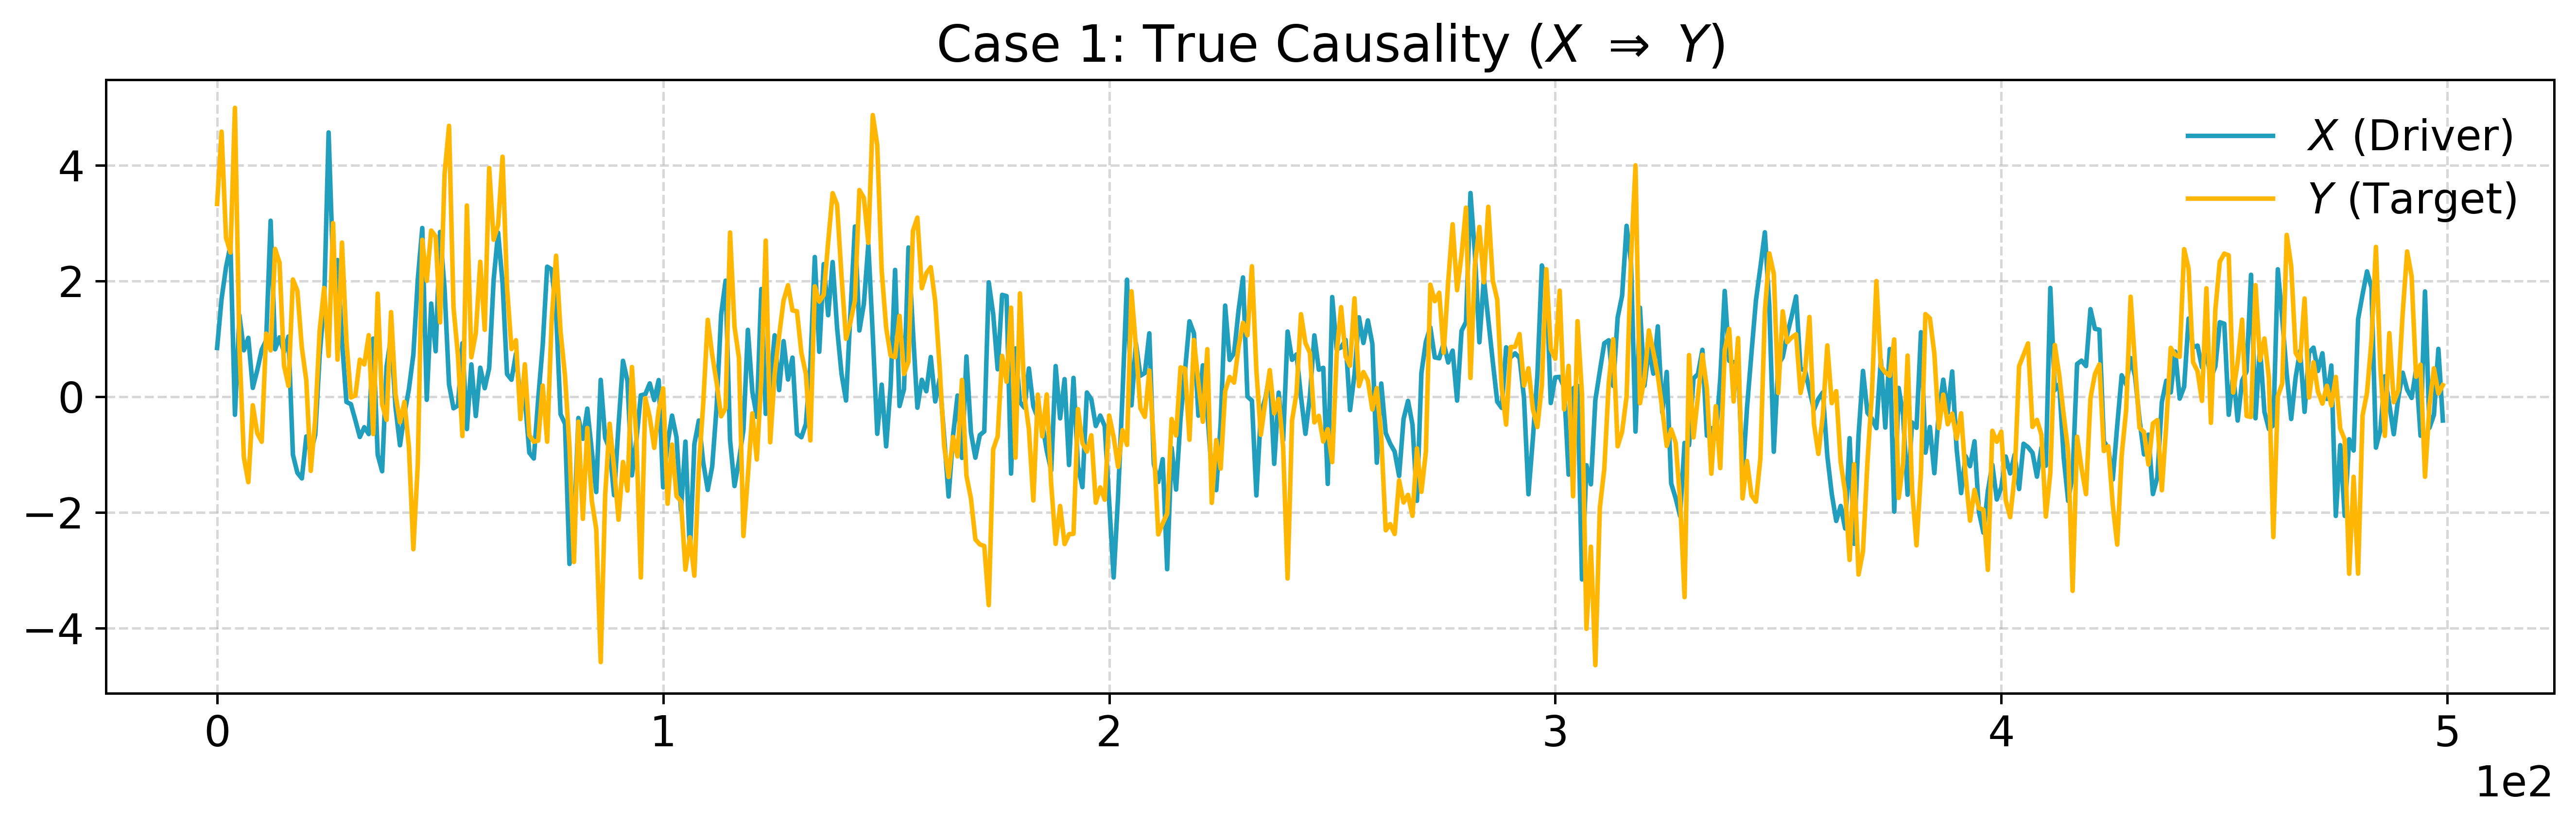

Test X => Y:
 Std Dev Restricted: 1.2153
 Std Dev Unrestricted: 0.9916 
 F: 1.50
 p-val: 7.4994e-11
Test Y => X:
 Std Dev Restricted: 1.0001
 Std Dev Unrestricted: 1.0000 
 F: 1.00
 p-val: 4.9787e-01



In [6]:
# Case 1: True Causality -- X => Y, but Y !=> X

print("========== Case 1: TRUE CAUSALITY (X => Y) ==========")
eps_X = np.random.normal(0, 1, N)
eps_Y = np.random.normal(0, 1, N)
X_true, Y_true = np.zeros(N), np.zeros(N)

for t in range(2, N):
    # Y depends on X, X does NOT depend on Y
    X_true[t] = 0.5 * X_true[t-1] + 0.2 * X_true[t-2] + eps_X[t]
    Y_true[t] = 0.4 * Y_true[t-1] + 0.1 * Y_true[t-2] + 0.6 * X_true[t-1] + eps_Y[t]

X_true, Y_true = X_true[burn_in:], Y_true[burn_in:]

validate_statistics(X_true, "X_true")
validate_statistics(Y_true, "Y_true")
plot_series(X_true, Y_true, "Case 1: True Causality ($X$ $\Rightarrow$ $Y$)")

# Test 1a: Does X cause Y? (Expect: YES)
sR, sU, f_stat, p_val = granger_causality_test(driver=X_true, target=Y_true, p_lags=2)
print(f"Test X => Y:\n Std Dev Restricted: {sR:.4f}\n Std Dev Unrestricted: {sU:.4f} \n F: {f_stat:.2f}\n p-val: {p_val:.4e}")

# Test 1b: Does Y cause X? (Expect: NO)
sR, sU, f_stat, p_val = granger_causality_test(driver=Y_true, target=X_true, p_lags=2)
print(f"Test Y => X:\n Std Dev Restricted: {sR:.4f}\n Std Dev Unrestricted: {sU:.4f} \n F: {f_stat:.2f}\n p-val: {p_val:.4e}\n")

========== Case 2: INDEPENDENT (NO CAUSALITY) ==========
Statistics for X_independent:

-> Mean: -0.0148, Std Dev: 1.3007
-> ADF p-value:  0.0000 (Stationary if < 0.05)
-> KPSS p-value: 0.1000 (Stationary if > 0.05)

Statistics for Y_independent:

-> Mean: 0.0064, Std Dev: 1.1390
-> ADF p-value:  0.0000 (Stationary if < 0.05)
-> KPSS p-value: 0.1000 (Stationary if > 0.05)



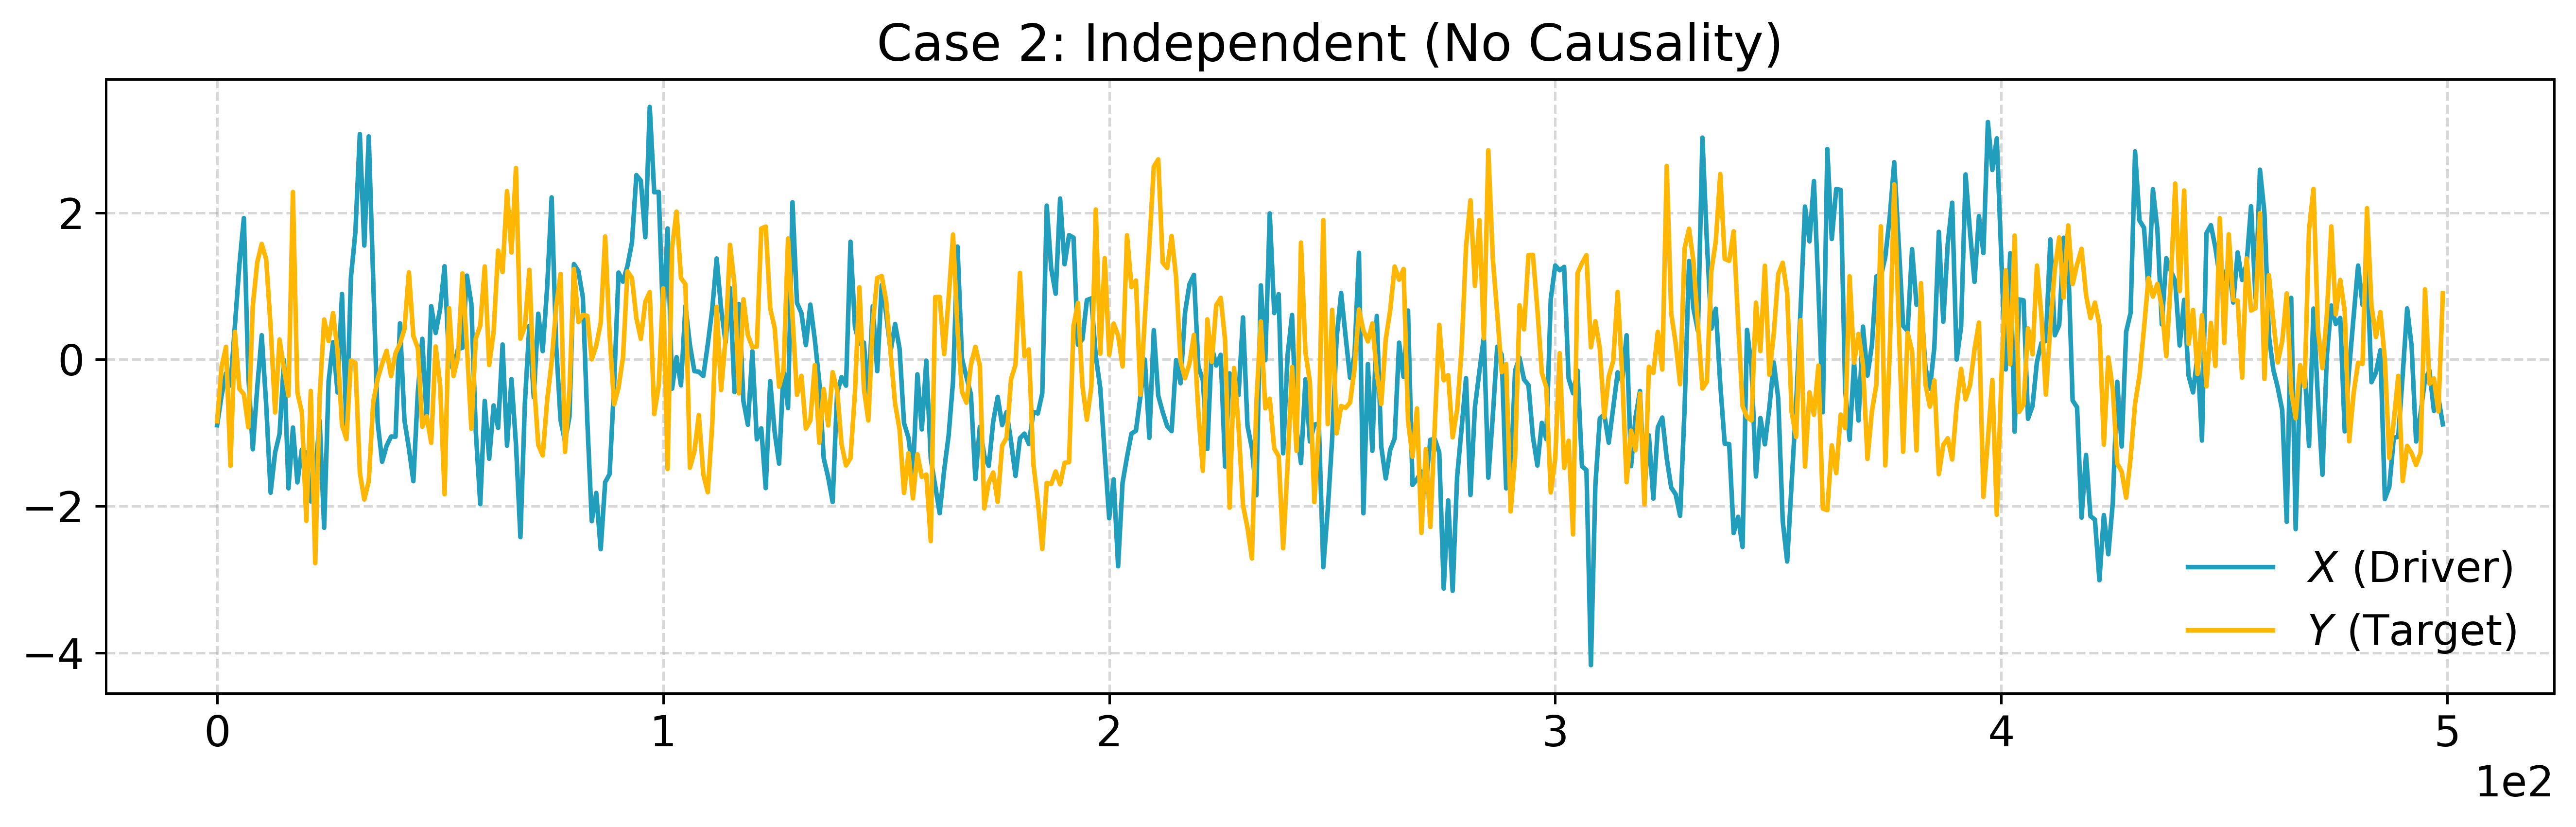

TESTING: X => Y
Result:
 Std Dev Restricted: 0.9838
 Std Dev Unrestricted: 0.9837 
 F: 1.00
 p-val: 4.9802e-01
TESTING: Y => X
Result:
 Std Dev Restricted: 0.9699
 Std Dev Unrestricted: 0.9715 
 F: 1.00
 p-val: 5.2014e-01



In [7]:
# Case 2: Independent Stationary Variables

print("========== Case 2: INDEPENDENT (NO CAUSALITY) ==========")
eps_X_ind = np.random.normal(0, 1, N)
eps_Y_ind = np.random.normal(0, 1, N)
X_ind, Y_ind = np.zeros(N), np.zeros(N)

for t in range(2, N):
    # Both depend ONLY on their own past. No coupling.
    X_ind[t] = 0.5 * X_ind[t-1] + 0.2 * X_ind[t-2] + eps_X_ind[t]
    Y_ind[t] = 0.4 * Y_ind[t-1] + 0.1 * Y_ind[t-2] + eps_Y_ind[t]

X_ind, Y_ind = X_ind[burn_in:], Y_ind[burn_in:]

validate_statistics(X_ind, "X_independent")
validate_statistics(Y_ind, "Y_independent")
plot_series(X_ind, Y_ind, "Case 2: Independent (No Causality)")

# Test 1c: Does X cause Y? (Expect: NO)
sR, sU, f_stat, p_val = granger_causality_test(driver=X_ind, target=Y_ind, p_lags=2)
print("TESTING: X => Y")
print(f"Result:\n Std Dev Restricted: {sR:.4f}\n Std Dev Unrestricted: {sU:.4f} \n F: {f_stat:.2f}\n p-val: {p_val:.4e}")

# Test 1d: Does Y cause X? (Expect: NO)
sR, sU, f_stat, p_val = granger_causality_test(driver=Y_ind, target=X_ind, p_lags=2)
print("TESTING: Y => X")
print(f"Result:\n Std Dev Restricted: {sR:.4f}\n Std Dev Unrestricted: {sU:.4f} \n F: {f_stat:.2f}\n p-val: {p_val:.4e}\n")

========== Case 3: FAILURE CASE (Hidden Variable) ==========
Statistics for X_hidden:

-> Mean: 0.0115, Std Dev: 1.7350
-> ADF p-value:  0.0000 (Stationary if < 0.05)
-> KPSS p-value: 0.1000 (Stationary if > 0.05)

Statistics for Y_hidden:

-> Mean: 0.0387, Std Dev: 1.6024
-> ADF p-value:  0.0000 (Stationary if < 0.05)
-> KPSS p-value: 0.1000 (Stationary if > 0.05)



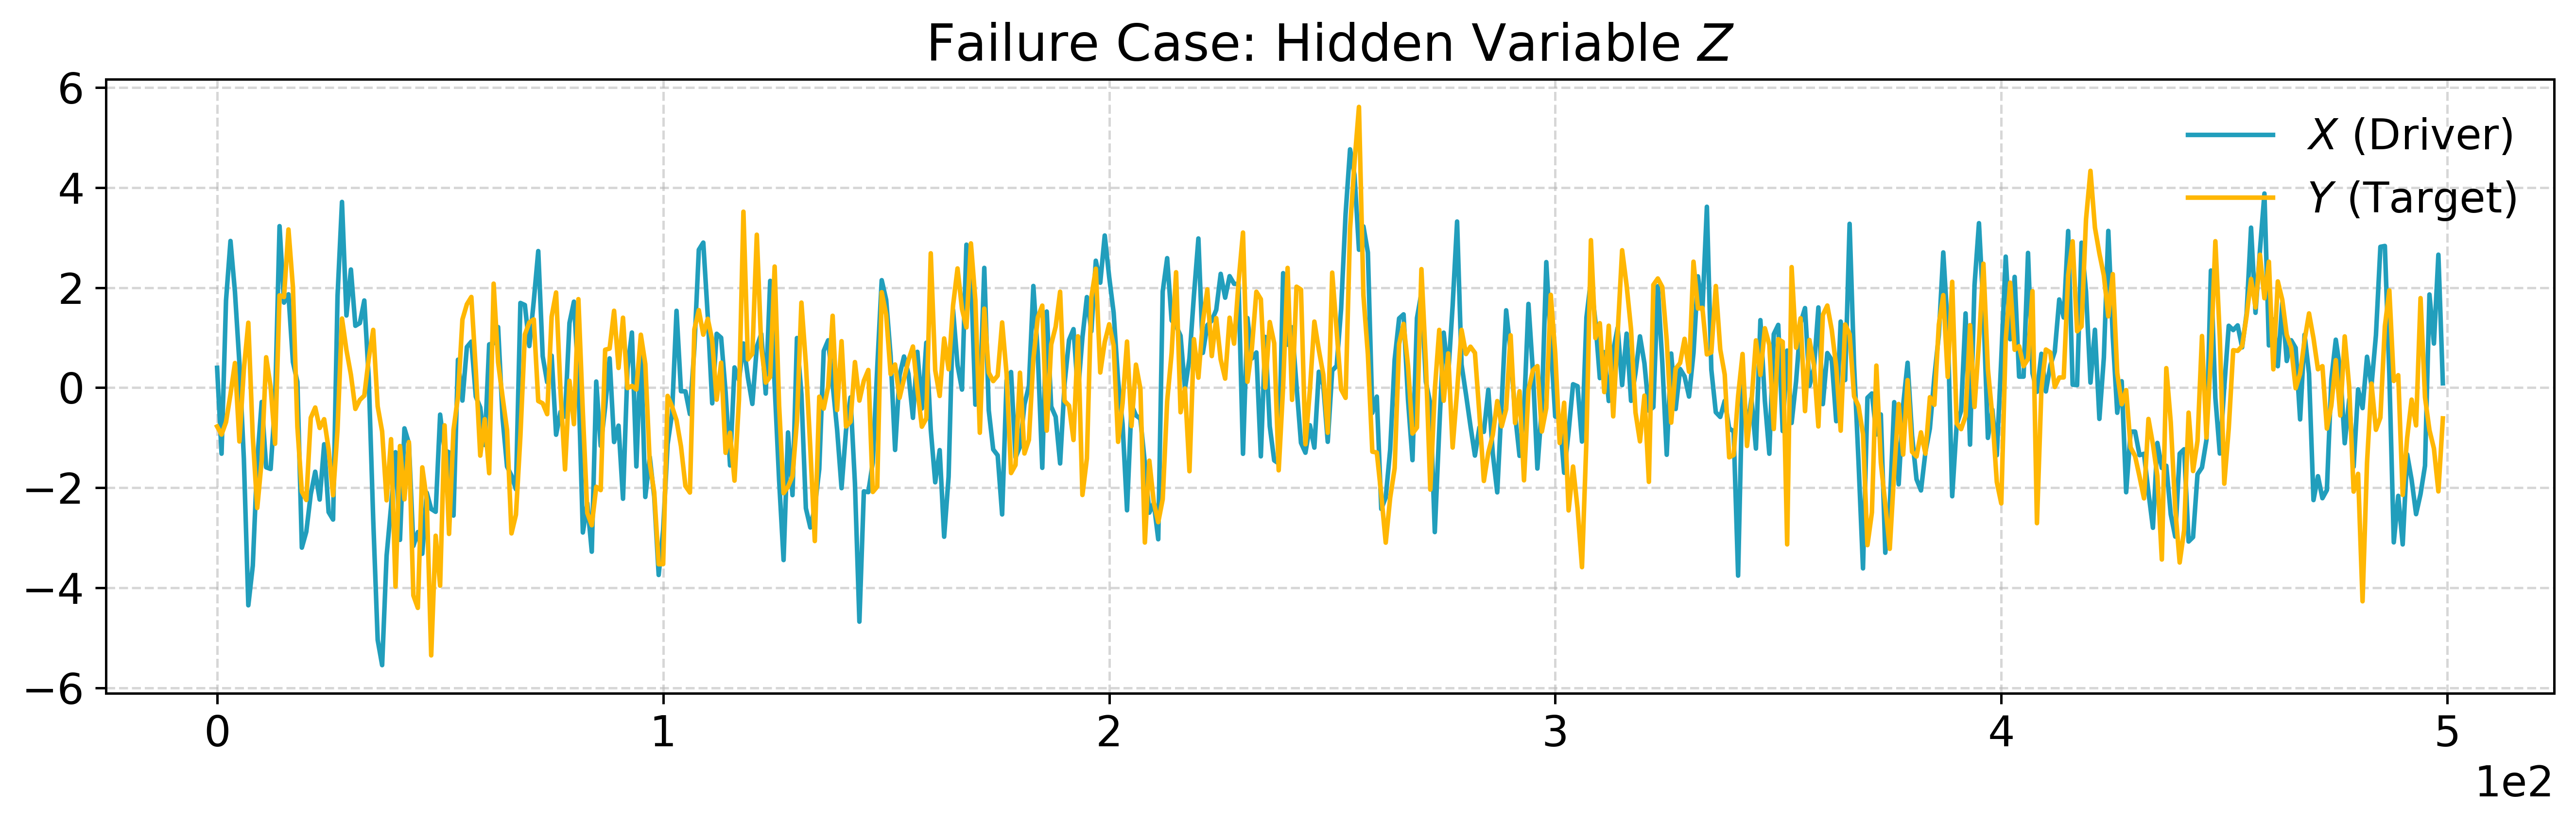

TESTING: X => Y (Without knowing Z exists)
Result:
 Std Dev Restricted: 1.3319
 Std Dev Unrestricted: 1.1903 
 F: 1.25
 p-val: 1.9431e-04


In [8]:
# Failure Case 1: The Hidden Variable

# Z causes both X and Y. X and Y do not cause each other.
print("========== Case 3: FAILURE CASE (Hidden Variable) ==========")
eps_Z = np.random.normal(0, 1, N)
Z_hid, X_hid, Y_hid = np.zeros(N), np.zeros(N), np.zeros(N)

for t in range(2, N):
    Z_hid[t] = 0.6 * Z_hid[t-1] + eps_Z[t]
    X_hid[t] = 0.4 * X_hid[t-1] + 0.8 * Z_hid[t-1] + np.random.normal(0, 1)
    Y_hid[t] = 0.3 * Y_hid[t-1] + 0.8 * Z_hid[t-2] + np.random.normal(0, 1)

X_hid, Y_hid = X_hid[burn_in:], Y_hid[burn_in:]

validate_statistics(X_hid, "X_hidden")
validate_statistics(Y_hid, "Y_hidden")
plot_series(X_hid, Y_hid, "Failure Case: Hidden Variable $Z$")

# We test if X causes Y, hiding Z from the algorithm.
sR, sU, f_stat, p_val = granger_causality_test(driver=X_hid, target=Y_hid, p_lags=2)
print("TESTING: X => Y (Without knowing Z exists)")
print(f"Result:\n Std Dev Restricted: {sR:.4f}\n Std Dev Unrestricted: {sU:.4f} \n F: {f_stat:.2f}\n p-val: {p_val:.4e}")

========== Case 4: FAILURE CASE (Non-Linearity) ==========
Statistics for X_NonLinear:

-> Mean: -0.0113, Std Dev: 1.3199
-> ADF p-value:  0.0000 (Stationary if < 0.05)
-> KPSS p-value: 0.1000 (Stationary if > 0.05)

Statistics for Y_NonLinear:

-> Mean: 2.7593, Std Dev: 2.8201
-> ADF p-value:  0.0000 (Stationary if < 0.05)
-> KPSS p-value: 0.1000 (Stationary if > 0.05)



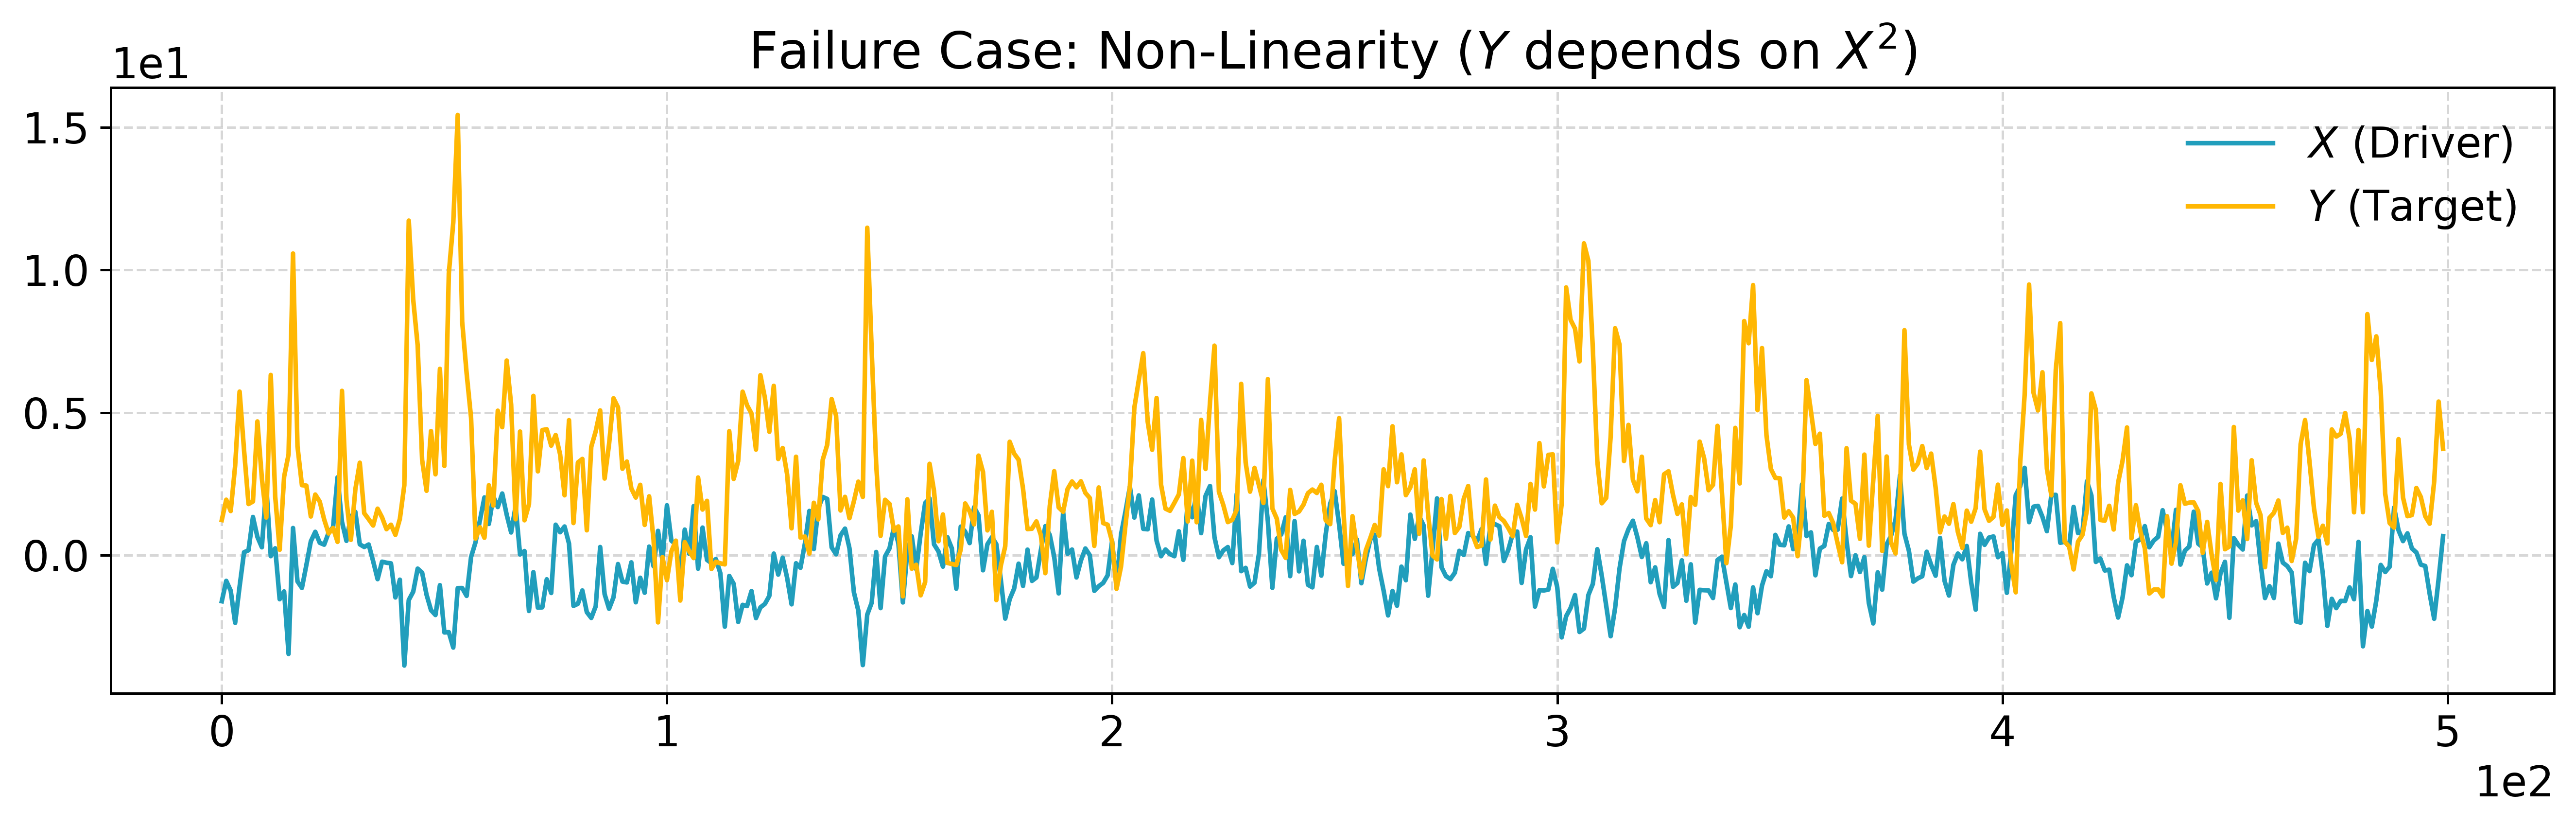

TESTING: X => Y
Result:
 Std Dev Restricted: 2.0442
 Std Dev Unrestricted: 2.0452 
 F: 1.00
 p-val: 5.0613e-01


In [9]:
# Failure Case 2: Non-Linearity

print("========== Case 4: FAILURE CASE (Non-Linearity) ==========")
eps_X_nl = np.random.normal(0, 1, N)
eps_Y_nl = np.random.normal(0, 1, N)
X_nl, Y_nl = np.zeros(N), np.zeros(N)

for t in range(2, N):
    X_nl[t] = 0.5 * X_nl[t-1] + 0.2 * X_nl[t-2] + eps_X_nl[t]
    
    # Causality actually exists: Y depends on the X^2
    Y_nl[t] = 0.4 * Y_nl[t-1] + 0.1 * Y_nl[t-2] + 0.8 * (X_nl[t-1]**2) + eps_Y_nl[t]

X_nl, Y_nl = X_nl[burn_in:], Y_nl[burn_in:]

validate_statistics(X_nl, "X_NonLinear")
validate_statistics(Y_nl, "Y_NonLinear")
plot_series(X_nl, Y_nl, "Failure Case: Non-Linearity ($Y$ depends on $X^2$)")

# Test if Linear OLS detects the true Non-Linear Causality
sR, sU, f_stat, p_val = granger_causality_test(driver=X_nl, target=Y_nl, p_lags=2)
print("TESTING: X => Y")
print(f"Result:\n Std Dev Restricted: {sR:.4f}\n Std Dev Unrestricted: {sU:.4f} \n F: {f_stat:.2f}\n p-val: {p_val:.4e}")